# Plotting

Use matplotlib, pandas, and plotly to leverage Python's power of data visualization. 

## Tools (Packages) for Plotting with Python

Several packages enable plotting in Python. The last page already introduced [NumPy](https://hydro-informatics.com/python-basics/pynum.html#numpy) and [pandas](https://hydro-informatics.com/python-basics/pynum.html#pandas) for plotting histograms. *pandas* plotting capacities go way beyond just plotting histograms and it relies on the powerful [matplotlib](https://matplotlib.org/) library. *SciPy*'s *matplotlib* is the most popular plotting library in *Python* (since its introduction in 2003) and not only *pandas*, but also other libraries (for example the abstraction layer [Seaborn](https://seaborn.pydata.org/)) use *matplotlib* with facilitated commands. This page introduces the following packages for data visualization:

* [matplotlib](https://hydro-informatics.com/python-basics/pynum.html#matplotlib) - the baseline for data visualization in Python
* [pandas](https://hydro-informatics.com/python-basics/pynum.html#pandas) - as wrapper API of *matplotlib*, with many simplified options for meaningful plots
* [plotly](https://hydro-informatics.com/jupyter/pyplot.html#interactive-plots-with-plotly) - for interactive plots, in which users can change and move plot scales 

## Matplotlib 

Because of its complexity and the fact that all important functions can be used with *pandas* in a much more manageable way, we will discuss *matplotlib* only briefly here. Yet it is important to know how *matplotlib* works to better understand the baseline of plotting with *Python* and to use more complex graphics or more plotting options when needed.

In 2003, the development of *matplotlib* was initiated in the field of neurobiology by [*John D. Hunter (&dagger;)*](https://en.wikipedia.org/wiki/John_D._Hunter) to emulate *The MathWorks*' *MATLAB&reg;* software. This early development constituted the `pylab` package, which is deprecated today for its bad practice of overwriting Python (in particular NumPy) `plot()` and `array()` methods/objects. Today, it is recommended to use:<br>
`import matplotlib.pyplot as plt`.

### Some Terms and Definitions
A `plt.figure` can be thought of as a box containing one or more axes, which represent the actual plots. Within the axes, there are smaller objects in the hierarchy such as markers, lines, legends, and text fields. Almost every element of a plot is a manipulable attribute and the most important attributes are shown in the following figure. More attributes can be found in the showcases of [matplotlib.org](https://matplotlib.org/examples/showcase/anatomy.html).


### Step-by-step Recipe for 1d/2d (line) Plots 

1. Import Matplotlib's plotting interface with `import matplotlib.pyplot as plt`.
1. Create a figure with `fig = plt.figure(figsize=(width, height), dpi=dpi)`.
1. Add an Axes with `ax = fig.add_subplot(nrows, ncols, index, label=label)`; for example, `ax = fig.add_subplot(1, 1, 1)`.
1. Obtain a colormap with `cmap = matplotlib.colormaps["plasma"]` and sample it with a normalized value such as `cmap(0.5)`.
1. Draw lines with `ax.plot(x, y, linestyle="-", marker="o", color=cmap(0.5))` or points with `ax.scatter(x, y, marker="x", color=colors)`.
1. Manipulate axis ticks
    * `plt.xticks(list)` define x-axis ticks
    * `plt.yticks(list)` define y-axis ticks
    * `axes.set_xlim(tuple(min, max))` sets the x-axis minimum and maximum
    * `axes.set_ylim(tuple(min, max))` sets the y-axis minimum and maximum
    * `axes.set_xlabel(str)` sets the x-axis label
    * `axes.set_ylabel(str)` sets the y-axis label
1. Add a legend (optionally) with `axes.legend(loc=str, facecolor=str, edgecolor=str, framealpha=float_between_0_and_1)` and many more `**kwargs` can be defined ([confer to the *matplotlib* docs](https://matplotlib.org/3.1.1/api/legend_api.html#matplotlib.legend.Legend)).
1. Optional: Save the figure with `plt.savefig(fname=str, dpi=int)` with many more `**kwargs` available ([confer to the *matplotlib* docs](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.savefig.html)).

> **Tip:** Most of the below illustrated `matplotlib` features are embedded in a plotter script, which is available at a [supplemental repository of the hydro-informatics.com eBook](https://raw.githubusercontent.com/hydro-informatics/material-py-codes/main/plotting/plotter.py).

The following code block illustrates a plot recipe using [randomly drawn samples from a *Weibull* distribution](https://numpy.org/doc/stable/reference/random/generated/numpy.random.RandomState.weibull.html#numpy.random.RandomState.weibull) with the distribution shape factor *a* (for `a=1`, the *Weibull* distribution reduces to an exponential distribution). The `seed` argument describes the source of randomness and `seed=None` makes Python use randomness from operating system variables.

The code block defines a function called `plot_xy` that requires `x` and `y` arguments and accepts the following optional keyword arguments:
* `plot_type=str` defines if a line or scatter plot should be produced,
* `label=str` sets the legend,
* `save=str` defines a path where the figure should be saved (the figure is not saved if nothing is provided). To activate saving a figure, use the optional keyword argument `save`, for example, `save='C:/temp/weibull.png'` saves the figure to a local `temp` folder on a Windows `C:` drive.

Plot lines


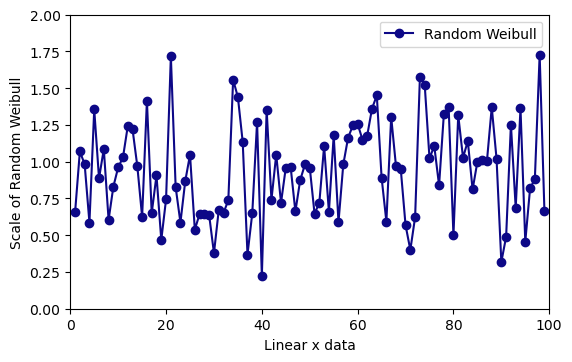

Scatter plot


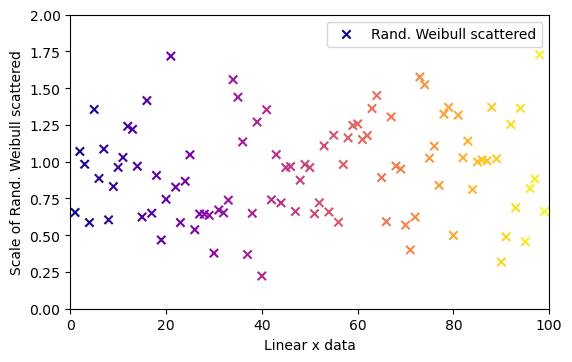

(<Figure size 618x382 with 1 Axes>,
 <AxesSubplot: xlabel='Linear x data', ylabel='Scale of Rand. Weibull scattered'>,
 <matplotlib.collections.PathCollection at 0x7c1171231880>)

In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
x = np.arange(1, 100)
y = np.random.RandomState(seed=None).weibull(3., len(x))

def plot_xy(x, y, plot_type="line", label="Random Weibull", save=None):
  fig, ax = plt.subplots(figsize=(6.18, 3.82), dpi=100)
  colors = cm.plasma(np.linspace(0, 1, len(y)))

  if plot_type == "line":
	  artist = ax.plot(x, y, linestyle="-", marker="o", color=colors[0], label=label)
  elif plot_type == "scatter":
	  artist = ax.scatter(x, y, marker="x", color=colors, label=label)
  else:
	  raise ValueError("plot_type must be 'line' or 'scatter'")

  ax.set_xlim(0, 100)
  ax.set_ylim(0, 2)
  ax.set_xlabel("Linear x data")
  ax.set_ylabel(f"Scale of {label}")
  ax.legend(loc="upper right")
  if save is not None:
	  fig.savefig(save)
  plt.show()
  return fig, ax, artist


print("Plot lines")    
plot_xy(x, y)
print("Scatter plot")
plot_xy(x, y, plot_type="scatter", label="Rand. Weibull scattered")

> **Challenge:** The `plot_xy` function has some weaknesses. For instance, if more arguments are provided, or `y` data is a multidimensional array (not *nx1* or *1xm*) that should produce multiple plot lines, the function will not work. So, how can you optimize the `plot_xy` function, to make it more robust and enable multi-line plotting?

### Surface and Contour Plots

*matplotlib* provides multiple options to plot X-Y-Z (2d/3d) data such as:

* Surface plots with color shades: [`axes.plot_surface(X, Y, Z)`](https://matplotlib.org/mpl_toolkits/mplot3d/tutorial.html#surface-plots) 
* Contour plots: [`axes.contour(X, Y, Z)`](https://matplotlib.org/mpl_toolkits/mplot3d/tutorial.html#contour-plots) 
* Contour plots with filled surfaces: [`axes.contourf(X, Y, Z)`](https://matplotlib.org/mpl_toolkits/mplot3d/tutorial.html#filled-contour-plots) 
* Surface plots with triangulated mesh: [`axes.plot_trisurf(X, Y, Z)`](https://matplotlib.org/mpl_toolkits/mplot3d/tutorial.html#tri-surface-plots) 
* Three-dimensional scatter plots: [`axes.scatter3D(X, Y, Z)`](https://matplotlib.org/3.1.1/gallery/mplot3d/scatter3d.html) 
* Streamplots (e.g., of velocity vectors): [`axes.streamplot(X, Y, U, V)`](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.streamplot.html) 
* Color-coded representation of gridded values with (annotated) heatmaps (e.g., for habitat suitability index maps): [`axes.imshow(data, **kwargs)`](https://matplotlib.org/3.1.1/gallery/images_contours_and_fields/image_annotated_heatmap.html)

This section features the usage of streamplots, which are a useful tool for the visualization of velocity vectors (flow fields) in rivers (e.g., produced with a numerical model). To generate a streamplot:

1. Create an `X` - `Y` grid, for example with the [NumPy's `mgrid` method](https://numpy.org/doc/stable/reference/generated/numpy.mgrid.html): `Y, X = np.mgrid[range, range]`
1. Assign stream field data (can be artificially generated, for example, in the form of `U` and `V` variables in the below code block) to the grid nodes. Note that every grid node can only get assigned one scalar value, which is `velocity` (as a function of the 2-directional field data) in the below code block.
1. Generate figures, as before in the `plot_xy` function example (see the above 1d/2d plot instructions).

The below code block illustrates the generation of a streamplot (adapted from the [matplotlib docs](https://matplotlib.org/3.1.1/gallery/images_contours_and_fields/plot_streamplot.html#sphx-glr-gallery-images-contours-and-fields-plot-streamplot-py)) and uses `import matplotlib.gridspec` to place the subplots in the figure.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# generate grid
w = 100
Y, X = np.mgrid[-w:w:10j, -w:w:10j]  # imaginary step specifies the number of evenly spaced samples

# calculate U and V vector matrices on the grid
U = -2 - X**2 + Y
V = 0 + X - Y**2

fig = plt.figure(figsize=(6., 2.5), dpi=200)
fig_grid = gridspec.GridSpec(nrows=1, ncols=2)
velocity = np.sqrt(U**2 + V**2)  # calculate velocity vector 

#  Varying line width along a streamline
axes1 = fig.add_subplot(fig_grid[0, 0])
axes1.streamplot(X, Y, U, V, density=0.6, color='b', linewidth=3*velocity/velocity.max())
axes1.set_title('Line width variation', fontfamily='Tahoma', fontsize=8, fontweight='bold')

# Varying color along a streamline
axes2 = fig.add_subplot(fig_grid[0, 1])
uv_stream = axes2.streamplot(X, Y, U, V, color=velocity, linewidth=2, cmap='Blues')
fig.colorbar(uv_stream.lines)
axes2.set_title('Color maps', fontfamily='Tahoma', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

### Fonts and Styles

The previous example featured a font type adjustment for the plot titles (`axes.set_title('title', font ...)`). The font and its characteristics (e.g., size, weight, style, or family) can be defined more coherently with `matplotlib.rc` ([see matplotlib docs](https://matplotlib.org/stable/api/font_manager_api.html)), where plot font settings can be globally modified within a script.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rc

# set font preferences
rc(
  "font",
  family="Times New Roman",
  style="italic",
  weight="semibold",
  size=10,
)

# make some plot data
x_lin = np.linspace(0.0, 10.0, 1000)  # evenly spaced numbers over a specific interval (start, stop, number-of-elements)
y_osc = np.cos(5 * np.pi * x_lin) * np.exp(-x_lin)

# plot
fig, axes = plt.subplots(figsize=(6.18, 1.8), dpi=150)
axes.plot(x_lin, y_osc, label="Oscillations")
axes.legend()
axes.set_xlabel("Time (s)")
axes.set_ylabel("Oscillation (V)")
plt.tight_layout()
plt.show()

Instead of using `rc`, font characteristics can also be updated with matplotlib's `rcParams` *dictionary*. In general, all font parameters can be accessed with `rcParams` along with many more parameters of plot layout options. The parametric options are stored in the [`matplotlibrc`](https://matplotlib.org/tutorials/introductory/customizing.html#customizing-with-matplotlibrc-files) file and can be accessed with `rcParams["matplotlibrc-parameter"]`. Read more about modification options (`"matplotlibrc-parameter"`) in the [*matplotlib* docs](https://matplotlib.org/tutorials/introductory/customizing.html#customizing-with-matplotlibrc-files). In order to modify a (font) style parameter use `rcParams.update({parameter-name: parameter-value})` (which does not always work, for example, in [jupyter](https://github.com/jupyter/notebook/issues/3385)). 

In addition, many default plot styles are available through [`matplotlib.style`](https://matplotlib.org/api/style_api.html#matplotlib-style) with many [style templates](https://matplotlib.org/gallery/style_sheets/style_sheets_reference.html). The following example illustrates the application of `rcParams` and `style` variables to the previously generated x-y oscillation dataset.

In [ ]:
from matplotlib import rcParams
from matplotlib import rcParamsDefault
from matplotlib import style
rcParams.update(rcParamsDefault)  # reset parameters in case you run this block multiple times
print("Some available serif fonts: " + ", ".join(rcParams['font.serif'][0:5]))
print("Some available sans-serif fonts: " + ", ".join(rcParams['font.sans-serif'][0:5]))
print("Some available monospace fonts: " + ", ".join(rcParams['font.monospace'][0:5]))
print("Some available fantasy fonts: " + ", ".join(rcParams['font.fantasy'][0:5]))

# change rcParams
rcParams.update({'font.fantasy': 'Impact'})  # has no effect here!

print("Some available styles: " + ", ".join(style.available[0:5]))
style.use('seaborn-v0_8-darkgrid')

# plot
fig, axes = plt.subplots(figsize=(6.18, 1.8), dpi=150)
axes.plot(x_lin, y_osc, label="Oscillations")
axes.legend()
axes.set_xlabel("Time (s)")
axes.set_ylabel("Oscillation (V)")
plt.tight_layout()
plt.show()

### Colors

The use of color maps is a sensitive topic: often default-set rainbow palettes map distinct hues that many viewers with color-vision deficiencies (approx. 1 in 12 men) cannot reliably differentiate. Consider the following aspects to accommodate perceptually uniform, colorblind-friendly colormaps:

* **Sequential (low > high):** use Matplotlib's `viridis`, `magma`, `plasma`, `inferno`; or domain-aware sequences from cmocean (see also below) to use, for instance, `cmo.thermal` for temperature, `cmo.haline` for salinity).
* **Diverging (midpoint emphasis):** use when values deviate around a meaningful center (0, climatology, etc.). Examples: Matplotlib's `seismic`-style but *perceptually tuned* options like `coolwarm` (still imperfect) or cmocean's `balance`, `delta`, `curl`, which are engineered for symmetry and lightness control.
* **Cyclic (wrap-around variables):** for phase/aspect (0°≡360°). Use cyclic maps such as cmocean's `phase`.
* **Categorical (discrete classes):** use distinct, desaturated palettes with good lightness separation; avoid "rainbow" categories for quantitative data.
* **Dynamic range:** ensure the lightness ramp spans the range where your audience needs discrimination (you can trim/clip the colormap range if needed).
* **Background:** pick a map whose lightness contrasts with the figure background (dark maps on dark backgrounds obscure low values).

To ease working with such colormaps, consider installing `cmocean`:

Below is an example of code for using perceptually uniform, colorblind-friendly colormaps. You can find this example also on [https://hydro-informatics.com/scilife/color-hacks.html](https://hydro-informatics.com/scilife/color-hacks.html).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

# Set a perceptually-uniform default
plt.rcParams["image.cmap"] = "viridis"

# Generate data
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)
Z = np.hypot(X, Y)

# Create sequential perceptually-uniform plot
plt.imshow(Z, origin="lower", cmap=cmocean.cm.thermal)
plt.colorbar(label="Temperature-like quantity")
plt.title("Sequential, perceptually-uniform")
plt.show()

### Annotations

Pointing out particularities in graphs is sometimes helpful to explain or name observations on graphs. The following code block shows some options with self-explaining *strings*.

In [ ]:
from matplotlib import rcParams
from matplotlib import rcParamsDefault
from matplotlib import style
rcParams.update(rcParamsDefault)  # reset parameters in case you run this block multiple times

fig, axes = plt.subplots(figsize=(10, 2.5), dpi=150)
style.use('fivethirtyeight')  #  let s just use still another style

fig.suptitle('This is the figure (super) title', fontsize=8, fontweight='bold')

axes.set_title('This is the axes (sub) title', fontsize=8)

axes.text(1, 0.8, 'B-boxed italic text with axis coords 1, 0.8', style='italic', fontsize=8, bbox={'facecolor': 'green', 'alpha': 0.5, 'pad': 5})
axes.text(5, 0.6, r'Annotation text with equation: $u=U^2 + V^2$', fontsize=8)
axes.text(7, 0.2, 'Color text with axis coords (7, 0.2)', verticalalignment='bottom', horizontalalignment='left', color='red', fontsize=8)

axes.plot([0.5], [0.2], 'x', markersize=7, color='blue')  #plot an arbitrary point
axes.annotate('Annotated point', xy=(0.5, 0.2), xytext=(2, 0.4), fontsize=8, arrowprops=dict(facecolor='blue', shrink=0.05))

axes.axis([0, 10, 0, 1])  # x_min, x_max, y_min, y_max

plt.show()

> **Challenge:** The above code blocks involve many repetitive statements such as `import ...` - `rcParams.update(rcParamsDefault)`, and `plot.show()` at the end. Can you write a [wrapper function](https://hydro-informatics.com/jupyter/pyfun.html#wrappers) to decorate a *matplotlib* plot function?

> **Exercise:** Familiarize with built-in plot functions using *matplotlib* with the template scripts provided with the [reservoir design](https://hydro-informatics.com/exercises/ex-sp) and [flood return period calculation](https://hydro-informatics.com/exercises/ex-floods) exercises.

## Plotting with *pandas*

Plotting with *matplotlib* can be daunting, not because the library is poorly documented (the complete opposite is the case), but because *matplotlib* is very extensive. *pandas* brings remedy with simplified commands for high-quality plots. The simplest way to plot a *pandas* data frame is [`pd.DataFrame.plot(x="col1", y="col2")`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html). The following example illustrates this fundamentally simple usage with a river discharge series stored in a workbook ([download example_flow_gauge.xlsx](https://raw.githubusercontent.com/hydro-informatics/jupyter-python-course/main/data/example_flow_gauge.xlsx)).

In [ ]:
import pandas as pd
flow_df = pd.read_excel('data/example_flow_gauge.xlsx', sheet_name='Mean Monthly CMS')
print(flow_df.head(3))
flow_df.plot(x="Date (mmm-jj)", y="Flow (CMS)", kind='line')

### *pandas* and *matplotlib*

Because *pandas* plot functionality roots in the *matplotlib* library, those can be easily combined, for example, to create subplots:

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm

flow_ex_df = pd.read_excel('data/example_flow_gauge.xlsx', sheet_name='FlowDuration')

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 2.5), dpi=150)
flow_ex_df.plot(x="Relative exceedance", y="Flow (CMS)", kind='area', color='DarkBlue', grid=True, title="Blue area plot", ax=axes[0])
flow_ex_df.plot(x="Relative exceedance", y="Flow (CMS)", kind='scatter', color="DarkGreen", title="Green scatter", marker="x", ax=axes[1])

### Boxplots and Error Bars

A [box-plot](https://en.wikipedia.org/wiki/Box_plot) graphically represents the distribution of (statistical) scatter and parameters of a data series.

Why use a box-plot with a *pandas* data frame? The reason is that with *pandas* data frames, we typically load data series with per-column statistical properties. For instance, if we run a steady-flow experiment in a hydraulic lab flume with ultrasonic probes for deriving water depths, we will observe signal fluctuation, even though the flow was steady. By loading the signal data into a *pandas* data frame, we can use a box plot to observe the average water depth and the noise in the measurement among different probes. Thus, probes with unexpected noise can be identified and repaired. This small example can be applied on a broader scale to many other sensors and for many other purposes (noise does not always mean that a sensor is broken). A box-plot has the following attributes:

* *boxes* represent the interquartile range (IQR), extending from the first quartile (Q1) to the third quartile (Q3). If notches are enabled, they indicate a confidence interval around the median.
* *medians* are horizontal lines marking the median within each box.
* *whiskers* are vertical lines extending from the box to data points determined by the specified `whis` rule.
* *caps* are small horizontal lines marking the ends of the whiskers.
* *fliers* are data points that fall beyond the whiskers and are therefore plotted individually.
* *means* are optional markers or lines indicating the dataset means.

*pandas* data frames make use of [`matplotlib.pyplot.boxplot`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.boxplot.html#matplotlib.pyplot.boxplot) to generate box-plots with [`df.boxplot()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.boxplot.html) or `df.plot.box()`. The following example features box-plots of water depth measurements with ultrasonic probes (sensors 1, 2, 3, and 5) stored in `FlowDepth009.csv` ([download](https://raw.githubusercontent.com/hydro-informatics/jupyter-python-course/main/data/FlowDepth009.csv)).

In [ ]:
us_sensor_df = pd.read_csv("data/FlowDepth009.csv", index_col=0, usecols=[0, 1, 2, 3, 5])
print(us_sensor_df.head(2))
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 2.5), dpi=150)
fontsize = 8.0
labels = ["S1", "S2", "S3", "S5"]

# make plot props dicts
diamond_fliers = dict(markerfacecolor='thistle', marker='D', markersize=2, linestyle=None)
square_fliers = dict(markerfacecolor='aquamarine', marker='+', markersize=3)
capprops = dict(color='deepskyblue', linestyle='-')
medianprops = {'color': 'purple', 'linewidth': 2}
boxprops = {'color': 'palevioletred', 'linestyle': '-'}
whiskerprops = {'color': 'darkcyan', 'linestyle': ':'}

us_sensor_df = us_sensor_df.rename(columns=dict(zip(list(us_sensor_df.columns), labels)))  # rename for plot conciseness
us_sensor_df.boxplot(fontsize=fontsize, ax=axes[0], labels=labels, widths=0.25, flierprops=diamond_fliers,
                     capprops=capprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops)
us_sensor_df.plot.box(color="tomato", vert=False, title="Hz. box-plot", flierprops=square_fliers, 
                      whis=0.75, fontsize=fontsize, meanline=True, showmeans=True, ax=axes[1], labels=labels)

Box-plots represent the statistical assets of datasets, but box-plots can quickly become confusing (messy) when they are presented in technical reports for multiple measurement series. Yet, it is state-of-the-art and good practice to present uncertainties in datasets in scientific and non-scientific publications, but somewhat more easily than, for example, with box-plots. To this end, so-called [error bars](https://en.wikipedia.org/wiki/Error_bar) can be added to data bars.  Error bars display a chosen uncertainty or variability measure around plotted values and may include lines, caps, and central markers. Depending on the measurement process, uncertainty may occur in x, y, both directions, or neither. State explicitly whether an error bar represents standard deviation, standard error, a confidence interval, instrument precision, or another quantity. The following example shows the application of error bars to bar plots of the above ultrasonic sensor data.

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 2.5), dpi=150)
# calculate stats
means = us_sensor_df.mean()
errors = us_sensor_df.std()
# make error bar bar plots
means.plot.bar(yerr=errors, capsize=4, color='palegreen', title="Error bars", width=0.3, fontsize=fontsize, ax=axes[0])
means.plot.barh(xerr=errors, capsize=5, color="lightsteelblue", title="Horizontal error bars", fontsize=fontsize, ax=axes[1])

> In scatter plots, errors are present in both *x* and *y* directions. For instance, the *x*-uncertainty may result from the measurement device precision, and *y*-uncertainty can be a result of signal processing. The above error measure in terms of the standard deviation is just an example of error amplitude. To measure and represent uncertainty correctly, always refer to device descriptions and assess precision effects of multiple devices or signal processing by calculating the [propagation of errors](https://en.wikipedia.org/wiki/Propagation_of_uncertainty).

More options for visualizing a *pandas* data frame is provided in the [developer's visualization docs](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html). Keep in mind that *matplotlib* can always be applied on top of a *pandas* plot.

## Interactive Plots with *plotly* 

The above shown *matplotlib* and *pandas* packages are great for creating static graphs in a desktop, report, or paper environment. Although interactive plots for web presentations can be created with *matplotlib* ([read more in the *matplotlib* docs](https://matplotlib.org/3.1.1/users/interactive.html)), the *plotly* library leverages many more interactive web plotting options within an easy-to-use API. *plotly* can also handle JSON-like data (hosted somewhere on the internet) to create web applications with *Dash*. Just one issue: the company behind (*Plotly*) is business-oriented...

### Installation
Plotly is not a default package neither in the `flusstools` environment file (*environment.yml*), nor in the *conda base* environment. Therefore, it must be installed manually with *conda prompt* (or *Conda Navigator* if you prefer the Desktop version). Plotly's Python graphing library is open-source and supports interactive, browser-based figures as well as static export. Install it in the active notebook environment with:

`%pip install plotly`

Install `anywidget` as well when using Plotly `FigureWidget` features. Restart the kernel if the environment requires it. Plotly also offers separate commercial products, but they are not required to use the open-source graphing library.
 
Read more about installing packages in a [conda environment](https://hydro-informatics.com/pyinstall#install-pckg) or [pip environment](https://hydro-informatics.com/pyinstall#pip-install-pckg).

### Usage (Simple Plots)

Plotly comes with datasets that can be queried online for showcases. The following example uses one of these datasets (find more at [plotly.com](https://plotly.com/python-api-reference/generated/plotly.express.data.html)).


In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.offline as pyo
pyo.init_notebook_mode() 
df = px.data.gapminder().query("continent=='Europe'")
fig = px.line(df, x="year", y="pop", color='country')
fig.show()
pyo.iplot(fig, filename='population')

In hydraulics, we often prefer to visualize data in locally stored text files, for example, after processing output from 2d-numerical modeling with NumPy or pandas. *plotly* works hand-in-hand with *pandas* and the following example features plotting *pandas* data frames, build from a *csv* file, with *ploty* (better solutions for *pandas* data frame sorting are shown in the [pandas reshaping section](https://hydro-informatics.com/jupyter/pynum.html#pd-reshape)). The following example uses `plotly.offline` to plot data in notebook mode (`pyo.init_notebook_mode()`) and `pyo.iplot()` can be used to write plot functions to a locally-living script for interactive plotting. The *csv* file comes from the *Food and Agriculture Organization of the United Nations* (FAO) data center [FAOSTAT](http://www.fao.org/faostat/en/#data/ET) ([download temperature_change.csv](https://raw.githubusercontent.com/hydro-informatics/jupyter-python-course/main/data/temperature_change.csv)).

In [ ]:
import plotly.graph_objects as go
import plotly.offline as pyo
import pandas as pd
pyo.init_notebook_mode()  # activate to create local function script

df = pd.read_csv("data/temperature_change.csv")

country_filter = "France"
month_filter1 = "January"
month_filter2 = "July"

df_country = df[df["Area"] == country_filter]
df_country_month1 = df_country[df_country["Months"] == month_filter1]
df_country_month2 = df_country[df_country["Months"] == month_filter2]

bar_plots = [
  go.Bar(x=df_country_month1["Year"], y=df_country_month1["Value"], name=month_filter1),
  go.Bar(x=df_country_month2["Year"], y=df_country_month2["Value"], name=month_filter2),
]
fig = go.Figure(data=bar_plots)
fig.update_layout(
  title=f"Monthly average surface temperature deviation (ref. 1951–1980) in {country_filter}",
  yaxis_title="Temperature (°C)",
)
fig.show()


# In local IDE use fig.show() - use iplot(fig) to procude local script for running figure functions
#fig.show(filename='basic-line2', include_plotlyjs=False, output_type='div')
pyo.iplot(fig, filename='temperature-evolution')

### Interactive map applications
*plotly* uses the [GeoJSON](https://en.wikipedia.org/wiki/GeoJSON) data format (an open standard for simple geospatial objects) in interactive maps. The developers provide many examples in their documentation and the below code block replicates a map representing unemployment rates in the United States. More examples are available at the [developer's website](https://plotly.com/python/maps/).

In [ ]:
import plotly.offline as pyo
from urllib.request import urlopen
import json
import pandas as pd

pyo.init_notebook_mode()  # only necessary in jupyter
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)


df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/fips-unemp-16.csv", dtype={"fips": str})

import plotly.express as px

fig = px.choropleth_map(df, geojson=counties, locations='fips', color='unemp',
                           color_continuous_scale="Viridis",
                           range_color=(0, 12),
                           map_style="carto-positron",
                           zoom=2, center = {"lat": 35.0, "lon": -90.0},
                           opacity=0.5,
                           labels={'unemp':'Unemployment rate (%)'}
                          )
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

Many more maps are available - some of them require a *Mapbox* account and the creation of a public token (read more at [plotly.com](https://plotly.com/python/mapbox-layers/)).